Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.3986 - loss: 0.5989 - val_accuracy: 0.8649 - val_loss: 0.6401 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4730 - loss: 0.5475 - val_accuracy: 0.8919 - val_loss: 0.6258 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5203 - loss: 0.5004 - val_accuracy: 0.9189 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5203 - loss: 0.5214 - val_accuracy: 0.9189 - val_loss: 0.6040 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5135 - loss: 0.4926 - val_accuracy: 0.9189 - val_loss: 0.5956 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5068 - loss: 0.4973 - val_accuracy: 0.9189 - val_loss: 0.5868 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5743 - loss: 0.4496 - val_accuracy: 0.9189

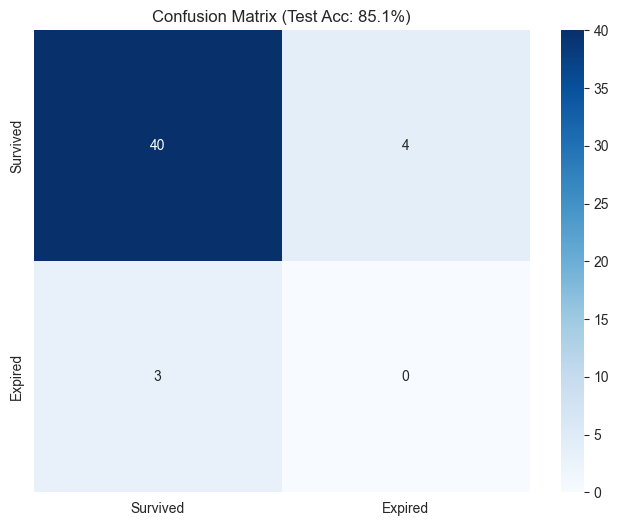

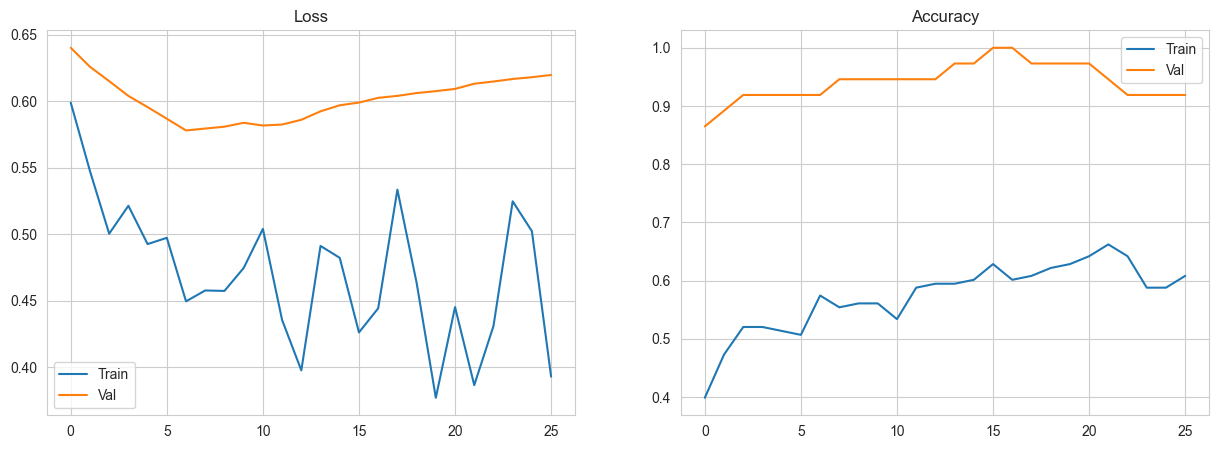

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

data_dir = r"C:\AINutriCare\Data\Transformed"
save_dir = r"C:\AINutriCare\Notebooks\Milestone_2"
os.makedirs(save_dir, exist_ok=True)

def get_input_path(filename): return os.path.join(data_dir, filename)
def get_save_path(filename): return os.path.join(save_dir, filename)

X = np.load(get_input_path('X_final.npy'))
y = np.load(get_input_path('y_final.npy'))
num_features = X.shape[2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: min(class_weights[0], 3.0), 1: min(class_weights[1], 3.0)}

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, num_features)
X_test_flat = X_test.reshape(-1, num_features)

scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

class SimpleAttention(Layer):
    def __init__(self, units=64, **kwargs):
        super(SimpleAttention, self).__init__()
        self.units = units
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W1 = self.add_weight(name='att_w1', shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform')
        self.W2 = self.add_weight(name='att_w2', shape=(self.units, 1),
                                 initializer='glorot_uniform')
        self.b1 = self.add_weight(name='att_b1', shape=(self.units,), initializer='zeros')
        super(SimpleAttention, self).build(input_shape)

    def call(self, x):
        h = tf.nn.tanh(tf.matmul(x, self.W1) + self.b1)
        e = tf.squeeze(tf.matmul(h, self.W2), -1)
        alpha = tf.nn.softmax(e)
        context = x * tf.expand_dims(alpha, -1)
        context = tf.reduce_sum(context, axis=1)
        return context, alpha

inputs = Input(shape=(24, num_features))
x = LSTM(64, return_sequences=True, dropout=0.4, recurrent_dropout=0.4)(inputs)
x = BatchNormalization()(x)
context, attention_weights = SimpleAttention()(x)
x = Dense(32, activation='relu')(context)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs, output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=4, min_lr=1e-5, mode='max')
]

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Survived', 'Expired']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Survived', 'Expired'], 
            yticklabels=['Survived', 'Expired'])
plt.title(f'Confusion Matrix (Test Acc: {test_acc*100:.1f}%)')
plt.show()

fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()

model.save(get_save_path('attention_lstm_87pct.h5'))
